#### Instructiuons

Please submit your solution via email in .txt format (code and results) and a .jpg/.png/etc. picture of your model formulation (can be handwritten, typed etc). Please label each file appropriately and make sure they are easily identified. Ensure readability and reproducibility; code should be well commented and easy to execute. You will use the dataset provided in the accompanying email. This challenge should take no more than 3 hours. Please focus on understanding/exploring the data as well as answering the client prompts below.

#### Challenge Description

Our client produces four types of cars: electric, compact, intermediate and luxury and two types of heavy vehicles, trucks and vans. Manufacturing limits total production capacity to at most 1,300,000 vehicles per year. Electrics and compacts are built together in a facility with a total annual capacity of 680,000 cars. Intermediate and luxury cars are produced in another facility with capacity of 430,000; and the heavy vehicle facility has a capacity of 315,000. Our client's marketing strategy requires that electrics and compacts must constitute at least half of the product mix for the four car types. Profit margins and market potential are summarized as follows:

![model](table.jpg)

#### Questions of Interest / Objective
According to government regulation, the average fleet fuel efficiency must be at least 30 MPG. Our client would like to use an optimization model to understand the implications of government and corporate policies on its production plans.
Using the cars dataset:

- What is the heaviest vehicle?
- What is the car with the highest fuel efficiency?
- Determine the average fuel efficiency of each type of vehicle
- Formulate a linear program to determine the maximum profit that can be achieved by our client.
- Solve the LP using a program of your choice.
- What is the maximum profit that can be obtained? How many and what percentage of total production will electric cars produced under this plan?

Optional Bonus Question:
- Unfortunately, due to supply chain and labor constraints, our client has a new requirement. Either luxury cars or trucks can be produced, but not both. Implement this requirement in the model.
- What is the new maximum profit that can be obtained? Of luxury cars and trucks, which type of vehicle will be produced?


#### Imports

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from plotnine import *
import warnings

seed = 1980

##### Get Data

In [72]:
# skip the second row -- data types
carsopt_df= pd.read_csv('./data/carsopt.txt', sep=';', skiprows=[1])  

# simplify col names
carsopt_df.columns = carsopt_df.columns.str.replace(" ", "_").str.lower()

carsopt_df.head()

,model,mpg,cylinders,displacement,horsepower,weight,acceleration,origin,vehicle
0,E-100a,100.0,0,307.0,130,3504,12.0,US,Electric
1,E-100b,124.0,0,350.0,165,3693,11.5,US,Electric
2,E-100c,109.0,0,318.0,150,3436,11.0,US,Electric
3,E-100d,106.0,0,304.0,150,3433,12.0,US,Electric
4,E-100e,121.0,0,302.0,140,3449,10.5,US,Electric


In [24]:
carsopt_df.dtypes

model            object
mpg             float64
cylinders         int64
displacement    float64
horsepower        int64
weight            int64
acceleration    float64
origin           object
vehicle          object
dtype: object

In [73]:
pd.concat([carsopt_df.describe(),
           carsopt_df.median(numeric_only=True).rename("median").to_frame().T,
          ])

,mpg,cylinders,displacement,horsepower,weight,acceleration
count,406.000000,406.000000,406.000000,406.000000,406.000000,406.000000
mean,54.004680,4.118227,194.779557,103.529557,2979.413793,15.519704
std,181.355055,2.606888,104.922458,40.520659,847.004328,2.803359
min,0.000000,0.000000,68.000000,0.000000,1613.000000,8.000000
25%,19.825000,4.000000,105.000000,75.000000,2226.500000,13.700000
50%,27.300000,4.000000,151.000000,93.500000,2822.500000,15.500000
75%,38.775000,6.000000,302.000000,129.000000,3618.250000,17.175000
max,3600.000000,8.000000,455.000000,230.000000,5140.000000,24.800000
median,27.300000,4.000000,151.000000,93.500000,2822.500000,15.500000


In [78]:
# lets look at it by vehicle type
carsopt_df.groupby('vehicle')[['mpg','cylinders','displacement','horsepower','weight','acceleration']].agg(['mean','median','min','max']).round(2)

mpg                        cylinders                 \
                mean  median    min     max      mean median min max   
vehicle                                                                
Compact        16.05   14.00   11.0    28.0      7.00    8.0   4   8   
Compcat        26.00   26.00   26.0    26.0      4.00    4.0   4   4   
Electirc      110.00  110.00  110.0   110.0      0.00    0.0   0   0   
Electric      114.74  114.00  100.0   130.0      0.00    0.0   0   0   
Elektric      106.00  106.00  106.0   106.0      0.00    0.0   0   0   
Intermediate   21.13   20.00   11.0    33.0      5.48    6.0   3   8   
Lux            28.32   28.25   17.5    37.3      4.50    4.0   4   8   
Luxury         66.85   20.70   13.0  3600.0      5.70    6.0   3   8   
Truck          41.25   32.25   19.1   400.0      4.24    4.0   3   6   
Van            29.59   30.85    0.0    44.0      4.52    4.0   4   8   

             displacement         ... horsepower        weight                \
                     mean median  ...        min  max     mean  median   min   
vehicle                           ...                                          
Compact            302.14  318.0  ...         80  225  3774.73  3904.5  2100   
Compcat             97.00   97.0  ...         46   46  1950.00  1950.0  1950   
Electirc           350.00  350.0  ...        165  165  4274.00  4274.0  4274   
Electric           242.52  250.0  ...          0  225  3242.05  3288.0  1613   
Elektric           360.00  360.0  ...        175  175  3850.00  3850.0  3850   
Intermediate       191.42  156.0  ...          0  230  3022.43  2922.0  1649   
Lux                131.50   97.5  ...         63  145  2473.25  2197.5  1945   
Luxury             199.66  200.0  ...         48  190  3036.63  3172.5  1800   
Truck              121.43  119.5  ...          0  132  2416.52  2427.0  1755   
Van                141.93  128.0  ...          0  120  2618.93  2630.0  1965   

                   acceleration                     
               max         mean median   min   max  
vehicle                                             
Compact       4997        13.82  13.50  11.0  18.0  
Compcat       1950        21.00  21.00  21.0  21.0  
Electirc      4274        12.00  12.00  12.0  12.0  
Electric      5140        14.29  14.00   8.0  23.5  
Elektric      3850        11.00  11.00  11.0  11.0  
Intermediate  4699        15.82  15.50   9.5  22.2  
Lux           3880        16.27  16.40  12.5  19.2  
Luxury        4360        15.73  15.30  11.1  24.8  
Truck         3381        16.28  16.05  11.3  23.7  
Van           3725        16.65  16.40  11.6  24.6  

[10 rows x 24 columns]

**Notes:** 
Someone really had fun making sure there were misspellings in vehicle, we'll fix these then look at the others

In [32]:
len(carsopt_df["model"].unique())

388

In [ ]:
carsopt_df['model'].unique()

array(['E-100a', 'E-100b', 'E-100c', 'E-100d', 'E-100e', 'E-100f',
       'E-100g', 'E-100h', 'E-100i', 'E-100j', 'E-100k', 'E-100l',
       'E-100m', 'E-100n', 'E-200a', 'E-200b', 'E-200c', 'E-200d',
       'E-200e', 'E-200f', 'E-200g', 'E-200h', 'E-200i', 'E-200j',
       'E-200k', 'E-300a', 'E-300b', 'E-300c', 'E-300d', 'E-300e',
       'E-300f', 'E-300g', 'E-300h', 'E-300i', 'E-300j', 'E-300k',
       'E-300l', 'E-300m', 'E-300n', 'E-300o', 'E-300p', 'E-300q',
       'E-300r', 'E-300s', 'E-300t', 'E-300u', 'E-300v', 'E-300w',
       'E-300x', 'E-300y', 'E-300z', 'E-350a', 'E-350b', 'E-350c',
       'E-350d', 'E-350e', 'E-350f', 'E-350g', 'E-350h', 'E-350i',
       'E-350j', 'E-350k', 'E-350l', 'E-350m', 'E-350n', 'E-400a',
       'E-400b', 'E-400c', 'E-400d', 'E-400e', 'E-400f', 'E-400g',
       'E-400h', 'E-400i', 'E-400j', 'E-400k', 'E-400l', 'E-400m',
       'E-400n', 'E-400o', 'E-400p', 'E-400q', 'E-400r', 'E-400s',
       'E-400t', 'E-400u', 'E-400v', 'E-400w', 'E-400x', 'C-10

In [37]:
len(carsopt_df['origin'].unique())

3

In [38]:
(carsopt_df['origin'].unique())

array(['US', 'Europe', 'Japan'], dtype=object)

In [39]:
len(carsopt_df['vehicle'].unique())

11

In [40]:
(carsopt_df['vehicle'].unique())

array(['Electric', 'Elektric', 'Electirc', 'Compact', 'Compcat',
       'Intermediate', 'Luxury', 'Lux', 'Truck', nan, 'Van'], dtype=object)

In [18]:
carsopt_df.isnull().sum()

model            0
mpg              0
cylinders        0
displacement     0
horsepower       0
weight           0
acceleration     0
origin           0
vehicle         10
dtype: int64

In [47]:

print((carsopt_df[carsopt_df.select_dtypes(include='number').columns] == 0).sum())

mpg              1
cylinders       89
displacement     0
horsepower       6
weight           0
acceleration     0
dtype: int64


**High Level Notes on Data:**

- 5 continuous variables
- 3 categorical variables 
- cylinders could be categorical depending on distribution (or can just be treated this way)
- Looking at the mean/medians most of the data is slightly skewed to the left or probably normally distributed
- There are only nulls iin the vehicle column, we'll look to see if they should be imputed or ust dropped. Since the vehicle type deteremines the margin we can only assign a type if the median values for types are very different and this aligns with one well

**Fixes:**
- Fix spelling errors with vehicle
- Look at nulls in vehicle
- Look at zeros in cylinders, horsepower and mgp and potentially impute

#### Data Cleansing

In [123]:
# Fix spelling in vehicle (
_vehicle_spelling = {
    "Elektric": "Electric",
    "Electirc": "Electric",
    "Compcat": "Compact",
    "Lux": "Luxury",
}

carsopt_clean = carsopt_df.copy()
carsopt_clean["vehicle"] = carsopt_df["vehicle"].replace(_vehicle_spelling)

(carsopt_clean['vehicle'].unique())

array(['Electric', 'Compact', 'Intermediate', 'Luxury', 'Truck', nan,
       'Van'], dtype=object)

In [124]:
# should look much better now
carsopt_clean.groupby('vehicle')[['mpg','cylinders','displacement','horsepower','weight','acceleration']].agg(['mean','median','min','max']).round(2)

mpg                        cylinders                 \
                mean  median    min     max      mean median min max   
vehicle                                                                
Compact        16.48   14.00   11.0    28.0      6.87    8.0   4   8   
Electric      114.58  114.00  100.0   130.0      0.00    0.0   0   0   
Intermediate   21.13   20.00   11.0    33.0      5.48    6.0   3   8   
Luxury         63.42   21.50   13.0  3600.0      5.59    6.0   3   8   
Truck          41.25   32.25   19.1   400.0      4.24    4.0   3   6   
Van            29.59   30.85    0.0    44.0      4.52    4.0   4   8   

             displacement         ... horsepower        weight                \
                     mean median  ...        min  max     mean  median   min   
vehicle                           ...                                          
Compact            293.22  318.0  ...         46  225  3695.39  3821.0  1950   
Electric           245.05  250.0  ...          0  225  3260.47  3302.0  1613   
Intermediate       191.42  156.0  ...          0  230  3022.43  2922.0  1649   
Luxury             193.60  163.0  ...         48  190  2986.56  3030.0  1800   
Truck              121.43  119.5  ...          0  132  2416.52  2427.0  1755   
Van                141.93  128.0  ...          0  120  2618.93  2630.0  1965   

                   acceleration                     
               max         mean median   min   max  
vehicle                                             
Compact       4997        14.13  14.00  11.0  21.0  
Electric      5140        14.23  14.00   8.0  23.5  
Intermediate  4699        15.82  15.50   9.5  22.2  
Luxury        4360        15.78  15.40  11.1  24.8  
Truck         3381        16.28  16.05  11.3  23.7  
Van           3725        16.65  16.40  11.6  24.6  

[6 rows x 24 columns]

In [79]:
# Look at nulls in vehicle
null_vehicle = carsopt_df[carsopt_df['vehicle'].isnull()]
null_vehicle

,model,mpg,cylinders,displacement,horsepower,weight,acceleration,origin,vehicle
354,V-100a,37.0,4,85.0,65,1975,19.4,Japan,NaN
355,V-100b,37.7,4,89.0,62,2050,17.3,Japan,NaN
356,V-100c,34.1,4,91.0,68,1985,16.0,Japan,NaN
357,V-100d,34.7,4,105.0,63,2215,14.9,US,NaN
358,V-100e,34.4,4,98.0,65,2045,16.2,US,NaN
359,V-100f,29.9,4,98.0,65,2380,20.7,US,NaN
360,V-100g,33.0,4,105.0,74,2190,14.2,Europe,NaN
361,V-100h,34.5,4,100.0,0,2320,15.8,Europe,NaN
362,V-100i,33.7,4,107.0,75,2210,14.4,Japan,NaN
363,V-100j,32.4,4,108.0,75,2350,16.8,Japan,NaN


In [96]:
# For rows with null vehicle: list models and check whether that model always
# carries a single `vehicle` value in non-missing rows (imputable from duplicates).
null_vehicle = carsopt_df[carsopt_df["vehicle"].isnull()]

models = null_vehicle["model"].unique()
rows = []
for m in models:
    sub = carsopt_df[carsopt_df["model"] == m]
    non_null = sub["vehicle"].dropna()
    rows.append(
        {
            "model": m,
            "n_rows_for_model": len(sub),
            "n_non_null_vehicle": len(non_null),
            "non_null_vehicles": sorted(non_null.unique().tolist()),
            "at_most_one_vehicle_type": non_null.nunique() <= 1,
        }
    )
vehicle_by_model = pd.DataFrame(rows).sort_values("model")
vehicle_by_model


,model,n_rows_for_model,n_non_null_vehicle,non_null_vehicles,at_most_one_vehicle_type
0,V-100a,1,0,[],True
1,V-100b,1,0,[],True
2,V-100c,1,0,[],True
3,V-100d,1,0,[],True
4,V-100e,1,0,[],True
5,V-100f,1,0,[],True
6,V-100g,1,0,[],True
7,V-100h,1,0,[],True
8,V-100i,1,0,[],True
9,V-100j,1,0,[],True


In [97]:
# we can impute these values from the non-null vehicle types
# this is a little heavy handed but maybe we'll need this down the line 
# Get the vehicle type from non-null rows with the same model prefix
prefix_map = (carsopt_clean.dropna(subset=['vehicle'])
              .assign(prefix=lambda x: x['model'].str.extract(r'^([A-Za-z]+)')[0])
              .groupby('prefix')['vehicle'].first())

carsopt_clean['prefix'] = carsopt_clean['model'].str.extract(r'^([A-Za-z]+)')
carsopt_clean['vehicle'] = carsopt_clean.apply(
    lambda row: prefix_map.get(row['prefix'], row['vehicle']) if pd.isnull(row['vehicle']) else row['vehicle'],
    axis=1)
carsopt_clean.drop(columns='prefix', inplace=True)

carsopt_clean[carsopt_clean['vehicle'].isnull()]

,model,mpg,cylinders,displacement,horsepower,weight,acceleration,origin,vehicle


In [99]:
# Look at zeros in cylinders, horsepower and mgp and potentially impute
print((carsopt_df[carsopt_df.select_dtypes(include='number').columns] == 0).sum())

mpg              1
cylinders       89
displacement     0
horsepower       6
weight           0
acceleration     0
dtype: int64


In [98]:
carsopt_df[carsopt_df['mpg'] == 0]

,model,mpg,cylinders,displacement,horsepower,weight,acceleration,origin,vehicle,prefix
367,V-200a,0.0,4,121.0,110,2800,15.4,Europe,Van,V


In [64]:
carsopt_df[carsopt_df['cylinders'] == 0]

,model,mpg,cylinders,displacement,horsepower,weight,acceleration,origin,vehicle
0,E-100a,100.0,0,307.0,130,3504,12.0,US,Electric
1,E-100b,124.0,0,350.0,165,3693,11.5,US,Electric
2,E-100c,109.0,0,318.0,150,3436,11.0,US,Electric
3,E-100d,106.0,0,304.0,150,3433,12.0,US,Electric
4,E-100e,121.0,0,302.0,140,3449,10.5,US,Electric
...,...,...,...,...,...,...,...,...,...
84,E-400t,115.0,0,121.0,76,2511,18.0,Europe,Electric
85,E-400u,110.0,0,120.0,87,2979,19.5,Europe,Electric
86,E-400v,108.0,0,96.0,69,2189,18.0,Europe,Electric
87,E-400w,111.0,0,122.0,86,2395,16.0,US,Electric


In [100]:
# let see if all electrics have 0 cylinders
carsopt_clean[carsopt_clean['vehicle'] == 'Electric']['cylinders'].value_counts()

cylinders
0    87
Name: count, dtype: int64

In [101]:
carsopt_df[carsopt_df['horsepower'] == 0]

,model,mpg,cylinders,displacement,horsepower,weight,acceleration,origin,vehicle,prefix
38,E-300n,105.0,0,98.0,0,2046,19.0,US,Electric,E
133,C-200c,21.0,6,200.0,0,2875,17.0,US,Intermediate,C
337,T-100z,400.0,4,85.0,0,1835,17.3,Europe,Truck,T
343,T-125f,23.6,4,140.0,0,2905,14.3,US,Truck,T
361,V-100h,34.5,4,100.0,0,2320,15.8,Europe,NaN,V
382,V-200p,23.0,4,151.0,0,3035,20.5,US,Van,V


In [102]:
# check to see if imputation is possible
for col in ['mpg', 'cylinders', 'horsepower']:
    zero_models = carsopt_df[carsopt_df[col] == 0]['model'].str.extract(r'^([A-Za-z]+-?\d+)')[0].unique()
    for m in zero_models:
        subset = carsopt_df[carsopt_df['model'].str.startswith(m)]
        non_zero = subset[subset[col] != 0][col]
        is_consistent = non_zero.nunique() == 1
        print(f"{col} | {m} | consistent: {is_consistent} | unique_vals: {non_zero.nunique()} | "
              f"mean: {non_zero.mean():.2f} | median: {non_zero.median():.2f} | std: {non_zero.std():.2f} | "
              f"values: {sorted(non_zero.unique())} | zero_count: {(subset[col]==0).sum()}")

mpg | V-200 | consistent: False | unique_vals: 14 | mean: 26.01 | median: 26.60 | std: 4.31 | values: [17.6, 20.2, 22.4, 23.0, 24.0, 24.2, 25.4, 26.6, 27.0, 28.0, 29.0, 30.7, 31.0, 34.0] | zero_count: 1
cylinders | E-100 | consistent: False | unique_vals: 0 | mean: nan | median: nan | std: nan | values: [] | zero_count: 14
cylinders | E-200 | consistent: False | unique_vals: 0 | mean: nan | median: nan | std: nan | values: [] | zero_count: 11
cylinders | E-300 | consistent: False | unique_vals: 0 | mean: nan | median: nan | std: nan | values: [] | zero_count: 26
cylinders | E-350 | consistent: False | unique_vals: 0 | mean: nan | median: nan | std: nan | values: [] | zero_count: 14
cylinders | E-400 | consistent: False | unique_vals: 0 | mean: nan | median: nan | std: nan | values: [] | zero_count: 24
horsepower | E-300 | consistent: False | unique_vals: 19 | mean: 125.84 | median: 100.00 | std: 50.15 | values: [46, 48, 87, 88, 90, 95, 100, 105, 113, 150, 153, 165, 170, 175, 180, 193, 

In [103]:
# we'll impute the mg and the horsepower, cylinders we will not that makes sense for electric 
for col in ['mpg', 'horsepower']:
    zero_models = carsopt_clean[carsopt_clean[col] == 0]['model'].str.extract(r'^([A-Za-z]+-?\d+)')[0].unique()
    for m in zero_models:
        non_zero = carsopt_clean[(carsopt_clean['model'].str.startswith(m)) & (carsopt_clean[col] != 0)][col]
        fill_val = non_zero.median()
        carsopt_clean.loc[(carsopt_clean['model'].str.startswith(m)) & (carsopt_clean[col] == 0), col] = fill_val

In [104]:
# Look at zeros in cylinders, horsepower and mgp and potentially impute
print((carsopt_clean[carsopt_clean.select_dtypes(include='number').columns] == 0).sum())

mpg              0
cylinders       89
displacement     0
horsepower       0
weight           0
acceleration     0
dtype: int64


**Notes:**


#### EDA

Distributions of Data

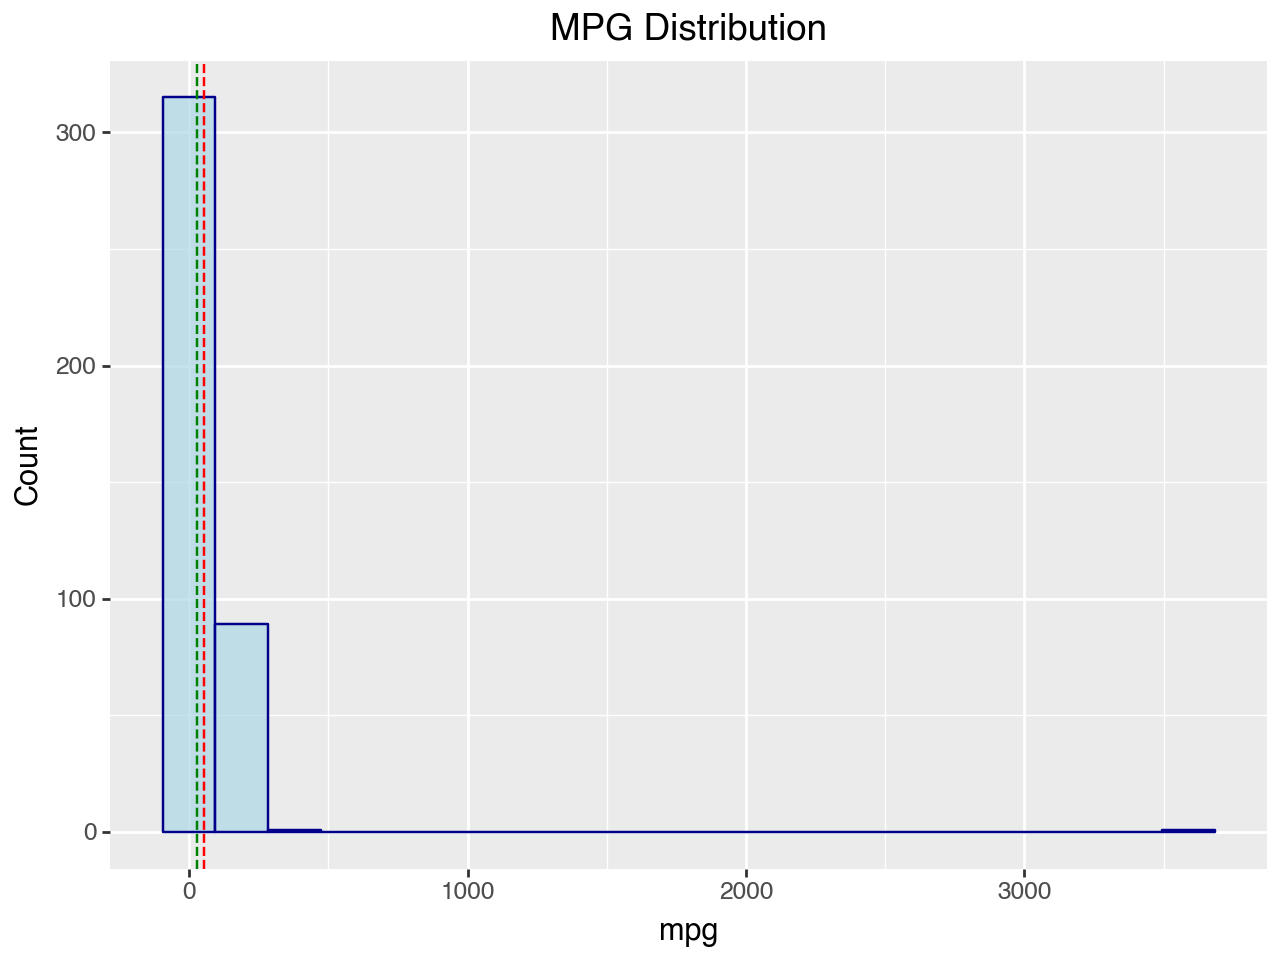

In [105]:
mean = carsopt_clean['mpg'].mean()
median = carsopt_clean['mpg'].median()

(ggplot(carsopt_clean, aes(x='mpg')) + 
        geom_histogram(bins = 20, 
                       fill = 'lightblue', 
                       color = 'darkblue',
                       alpha = 0.7) +
        labs(title = 'MPG Distribution', x = 'mpg', y = 'Count') + 
        geom_vline(xintercept=mean, color='red', linetype='dashed') +
        geom_vline(xintercept=median, color='green', linetype='dashed'))

In [126]:
# let's take a look at the outliers
carsopt_clean[carsopt_clean['mpg'] > 1000]

,model,mpg,cylinders,displacement,horsepower,weight,acceleration,origin,vehicle,prefix


In [127]:
#impute the median mpg for the L-150 model
l150_median = carsopt_clean[(carsopt_clean['model'].str.startswith('L-')) & (carsopt_clean['mpg'] < 1000)]['mpg'].median()
carsopt_clean.loc[(carsopt_clean['model'] == 'L-150') & (carsopt_clean['mpg'] > 1000), 'mpg'] = l150_median

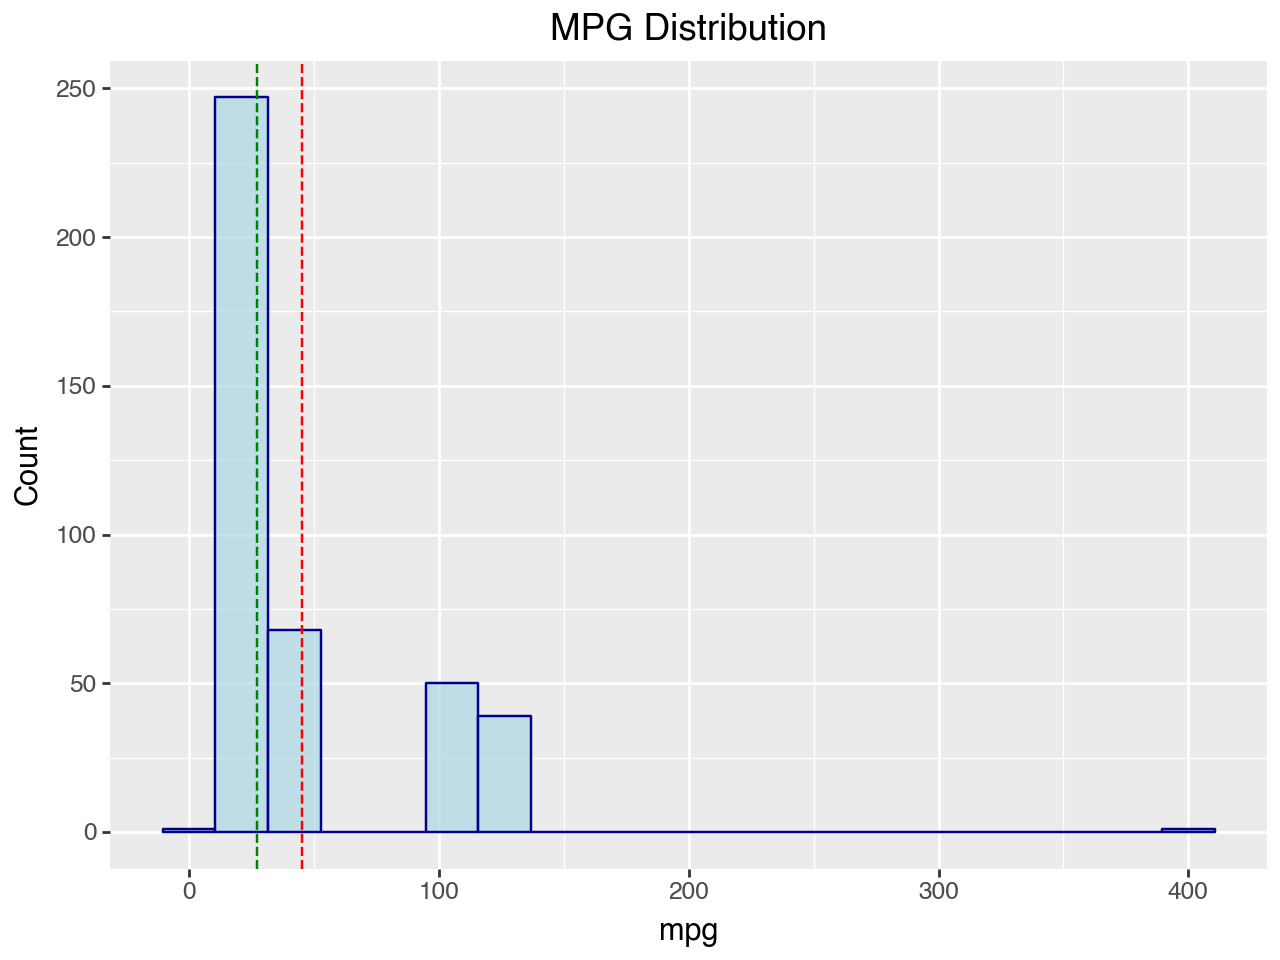

In [129]:
mean = carsopt_clean['mpg'].mean()
median = carsopt_clean['mpg'].median()

(ggplot(carsopt_clean, aes(x='mpg')) + 
        geom_histogram(bins = 20, 
                       fill = 'lightblue', 
                       color = 'darkblue',
                       alpha = 0.7) +
        labs(title = 'MPG Distribution', x = 'mpg', y = 'Count') + 
        geom_vline(xintercept=mean, color='red', linetype='dashed') +
        geom_vline(xintercept=median, color='green', linetype='dashed'))

In [130]:
# let's take a look at the outliers
carsopt_clean[carsopt_clean['mpg'] > 399]

,model,mpg,cylinders,displacement,horsepower,weight,acceleration,origin,vehicle,prefix
337,T-100z,400.0,4,85.0,0,1835,17.3,Europe,Truck,T


In [132]:
#impute the median mpg for the t100 model
t100_median = carsopt_clean[(carsopt_clean['model'].str.startswith('T-100')) & (carsopt_clean['mpg'] < 400)]['mpg'].median()
carsopt_clean.loc[(carsopt_clean['model'] == 'T-100z') & (carsopt_clean['mpg'] > 399), 'mpg'] = t100_median

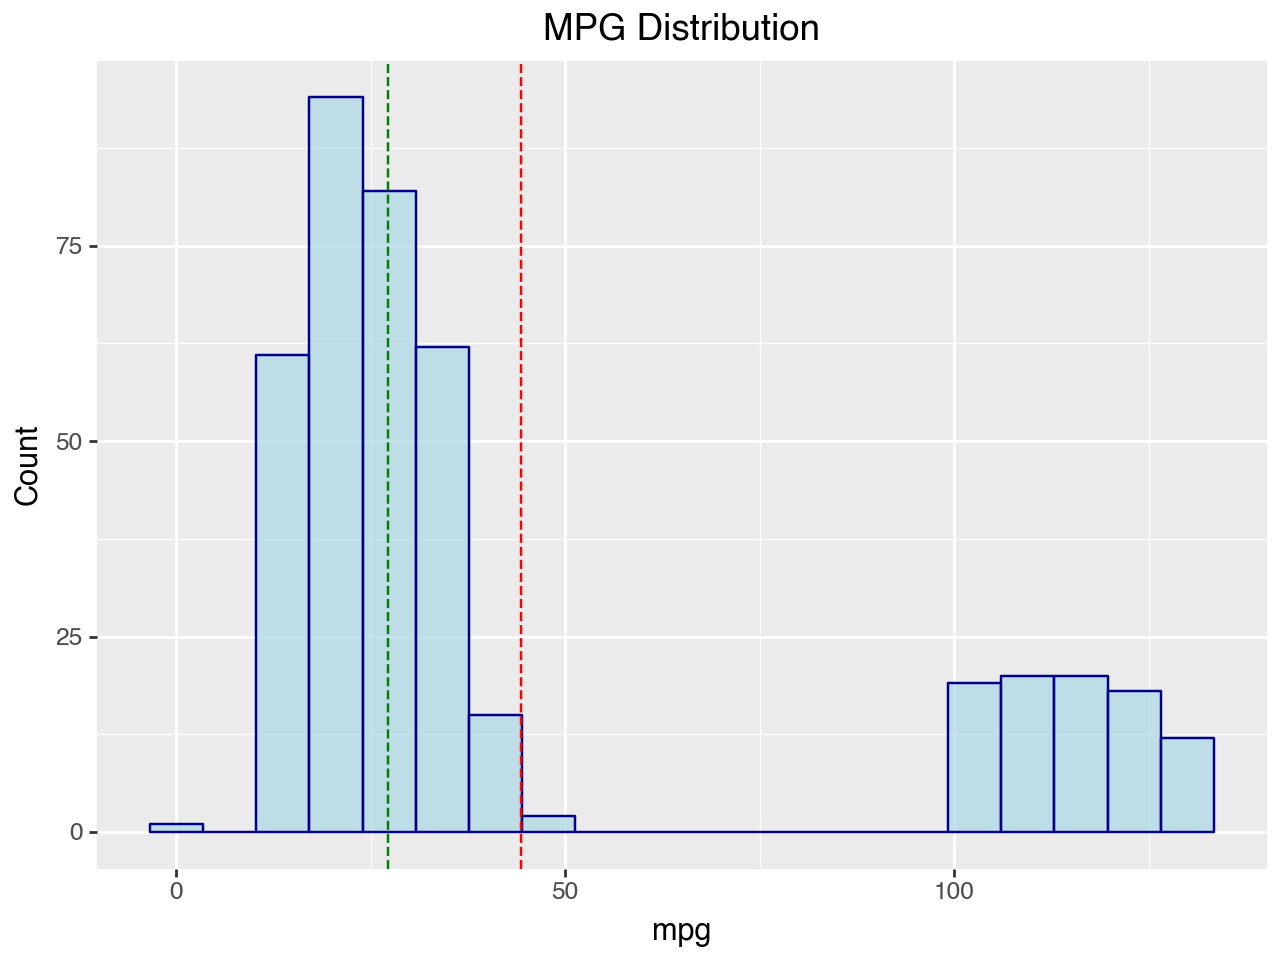

In [134]:
mean = carsopt_clean['mpg'].mean()
median = carsopt_clean['mpg'].median()

(ggplot(carsopt_clean, aes(x='mpg')) + 
        geom_histogram(bins = 20, 
                       fill = 'lightblue', 
                       color = 'darkblue',
                       alpha = 0.7) +
        labs(title = 'MPG Distribution', x = 'mpg', y = 'Count') + 
        geom_vline(xintercept=mean, color='red', linetype='dashed') +
        geom_vline(xintercept=median, color='green', linetype='dashed'))

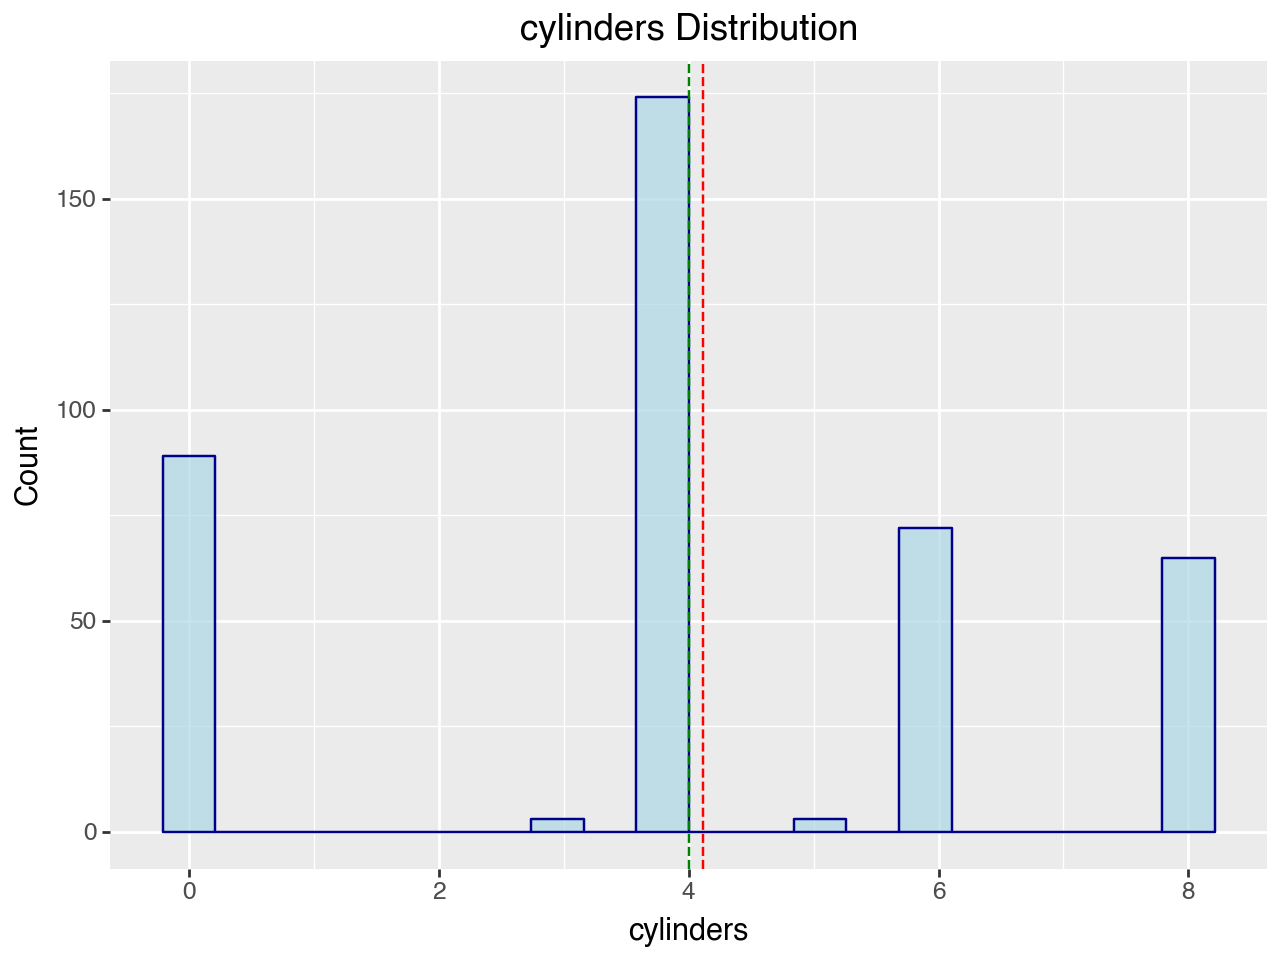

In [133]:
mean = carsopt_clean['cylinders'].mean()
median = carsopt_clean['cylinders'].median()

(ggplot(carsopt_clean, aes(x='cylinders')) + 
        geom_histogram(bins = 20, 
                       fill = 'lightblue', 
                       color = 'darkblue',
                       alpha = 0.7) +
        labs(title = 'cylinders Distribution', x = 'cylinders', y = 'Count') + 
        geom_vline(xintercept=mean, color='red', linetype='dashed') +
        geom_vline(xintercept=median, color='green', linetype='dashed'))

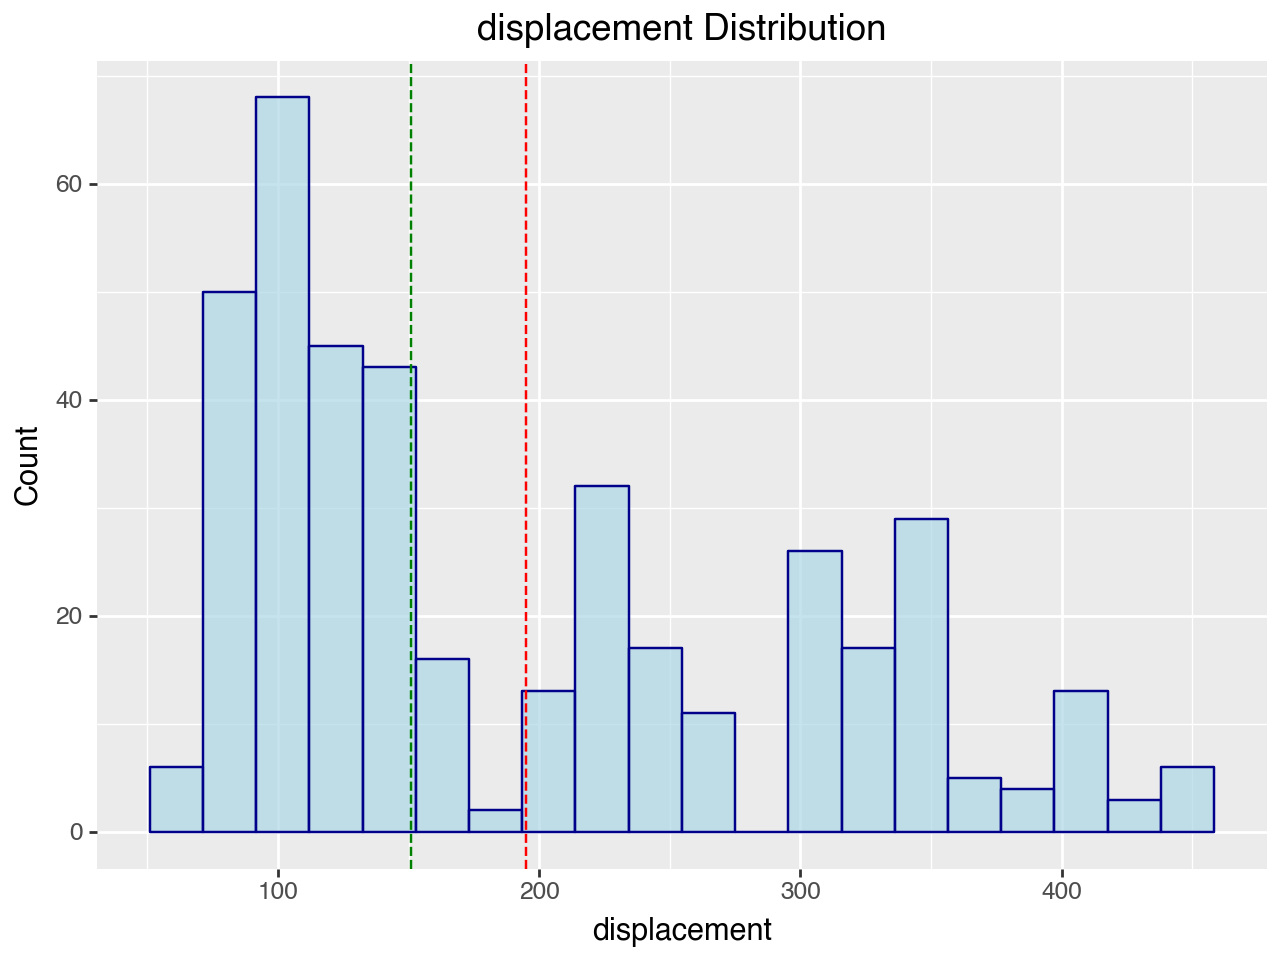

In [108]:
mean = carsopt_clean['displacement'].mean()
median = carsopt_clean['displacement'].median()

(ggplot(carsopt_clean, aes(x='displacement')) + 
        geom_histogram(bins = 20, 
                       fill = 'lightblue', 
                       color = 'darkblue',
                       alpha = 0.7) +
        labs(title = 'displacement Distribution', x = 'displacement', y = 'Count') + 
        geom_vline(xintercept=mean, color='red', linetype='dashed') +
        geom_vline(xintercept=median, color='green', linetype='dashed'))

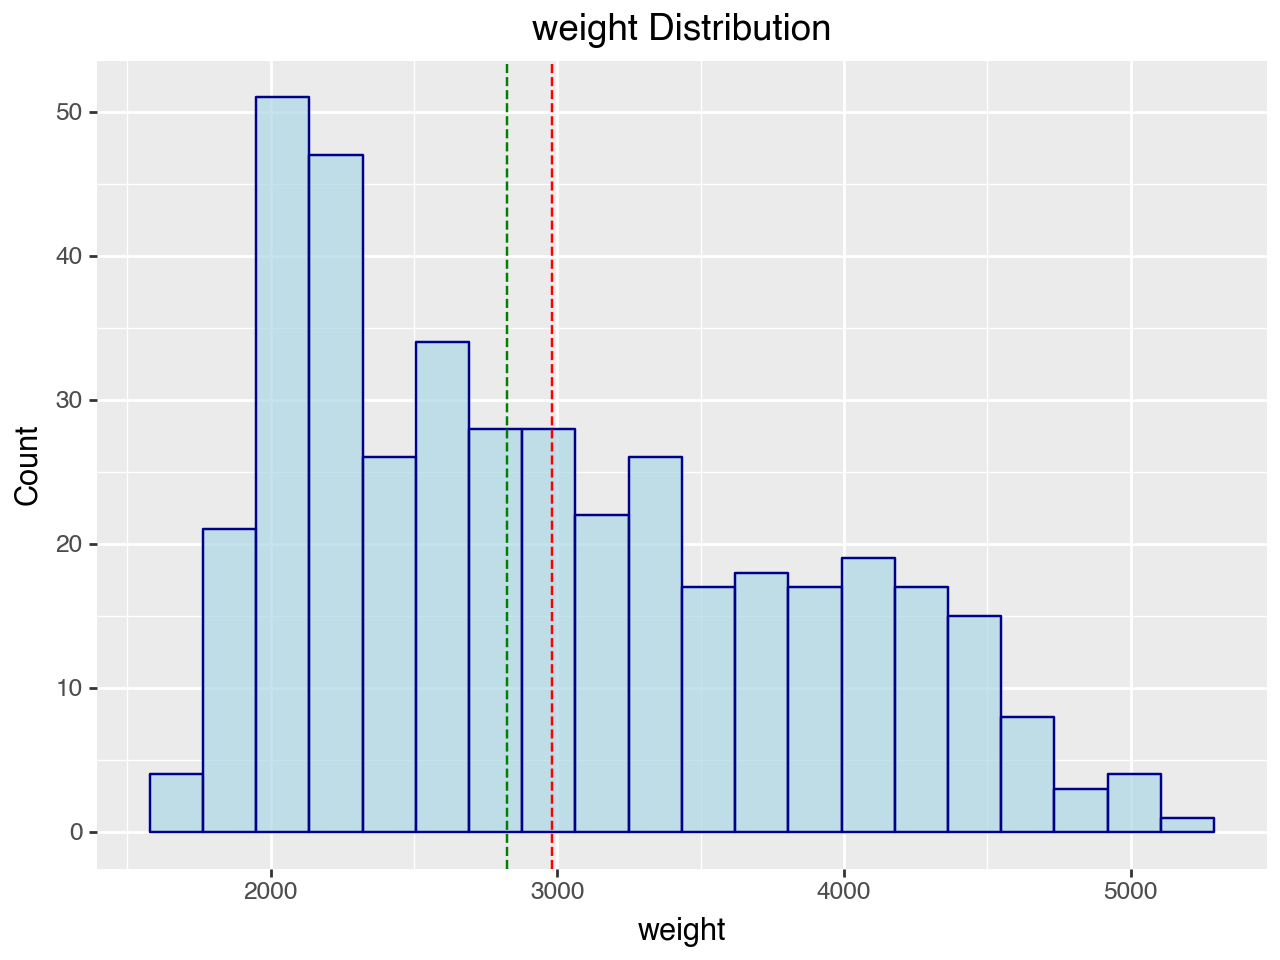

In [109]:
mean = carsopt_clean['weight'].mean()
median = carsopt_clean['weight'].median()

(ggplot(carsopt_clean, aes(x='weight')) + 
        geom_histogram(bins = 20, 
                       fill = 'lightblue', 
                       color = 'darkblue',
                       alpha = 0.7) +
        labs(title = 'weight Distribution', x = 'weight', y = 'Count') + 
        geom_vline(xintercept=mean, color='red', linetype='dashed') +
        geom_vline(xintercept=median, color='green', linetype='dashed'))

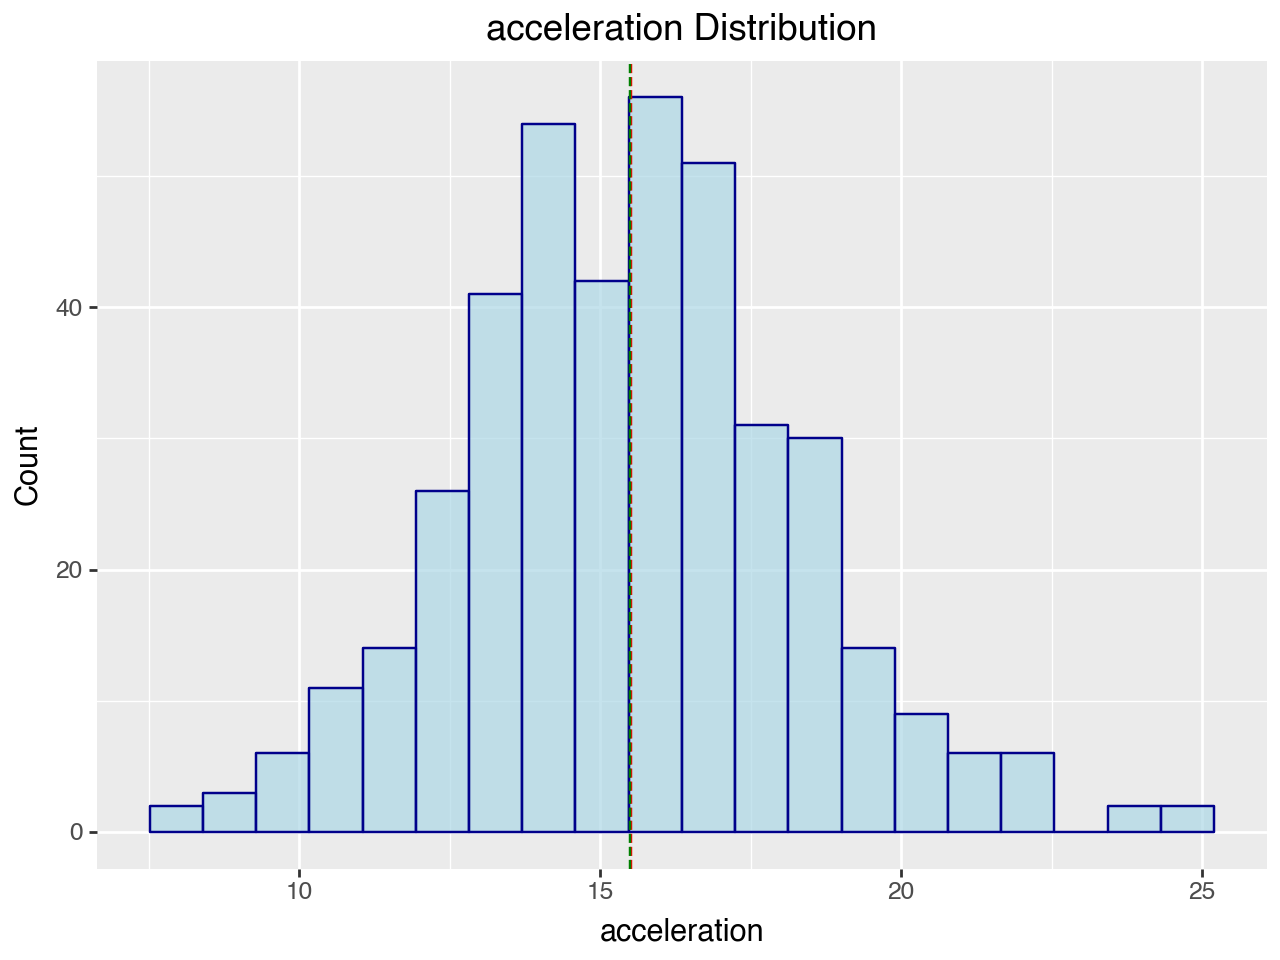

In [111]:
mean = carsopt_clean['acceleration'].mean()
median = carsopt_clean['acceleration'].median()

(ggplot(carsopt_clean, aes(x='acceleration')) + 
        geom_histogram(bins = 20, 
                       fill = 'lightblue', 
                       color = 'darkblue',
                       alpha = 0.7) +
        labs(title = 'acceleration Distribution', x = 'acceleration', y = 'Count') + 
        geom_vline(xintercept=mean, color='red', linetype='dashed') +
        geom_vline(xintercept=median, color='green', linetype='dashed'))

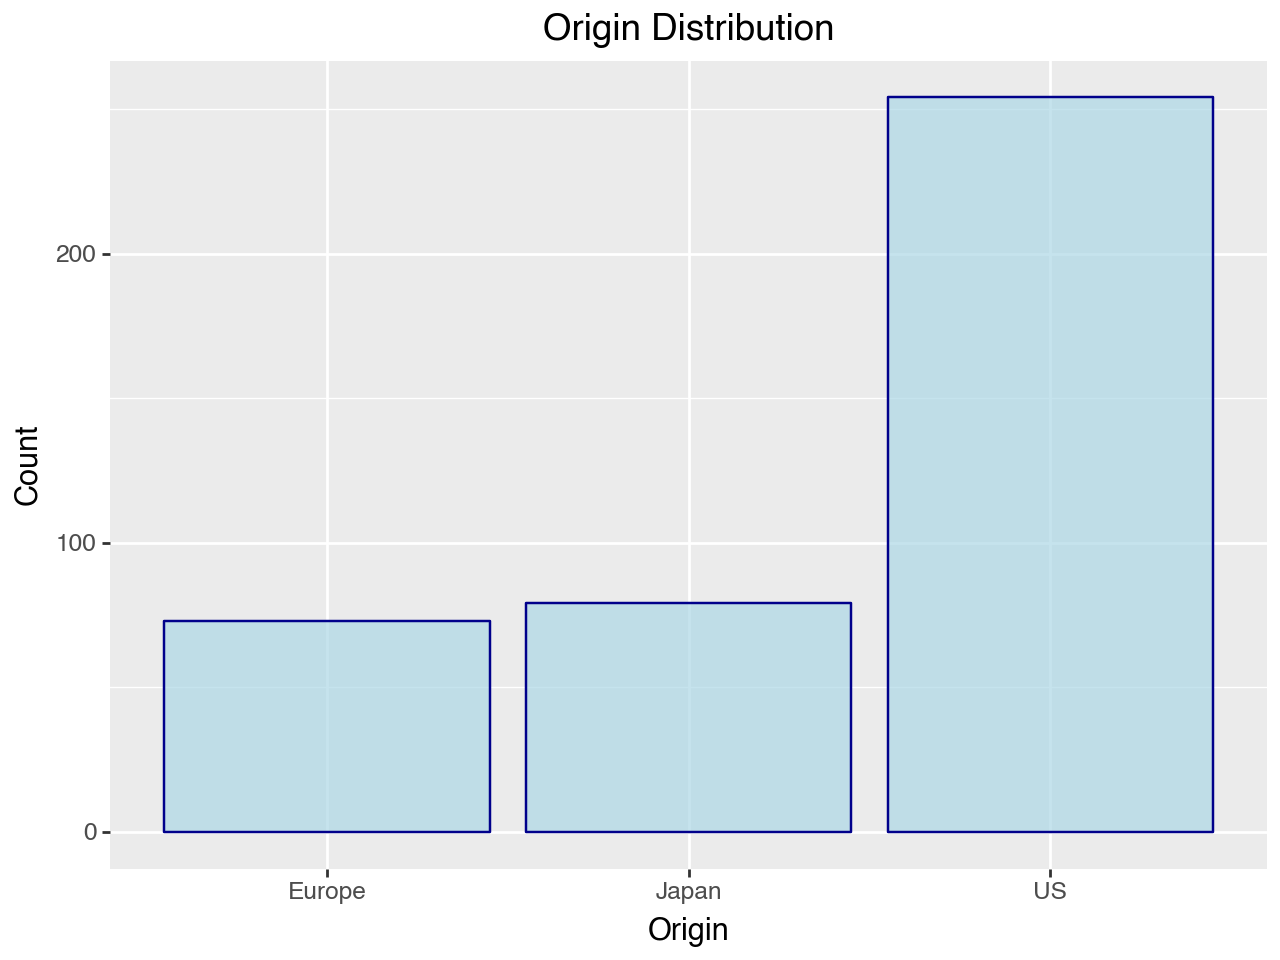

In [117]:
(ggplot(carsopt_clean, aes(x='origin'))
 + geom_bar(fill='lightblue', color='darkblue', alpha=0.7)
 + labs(title='Origin Distribution', x='Origin', y='Count'))

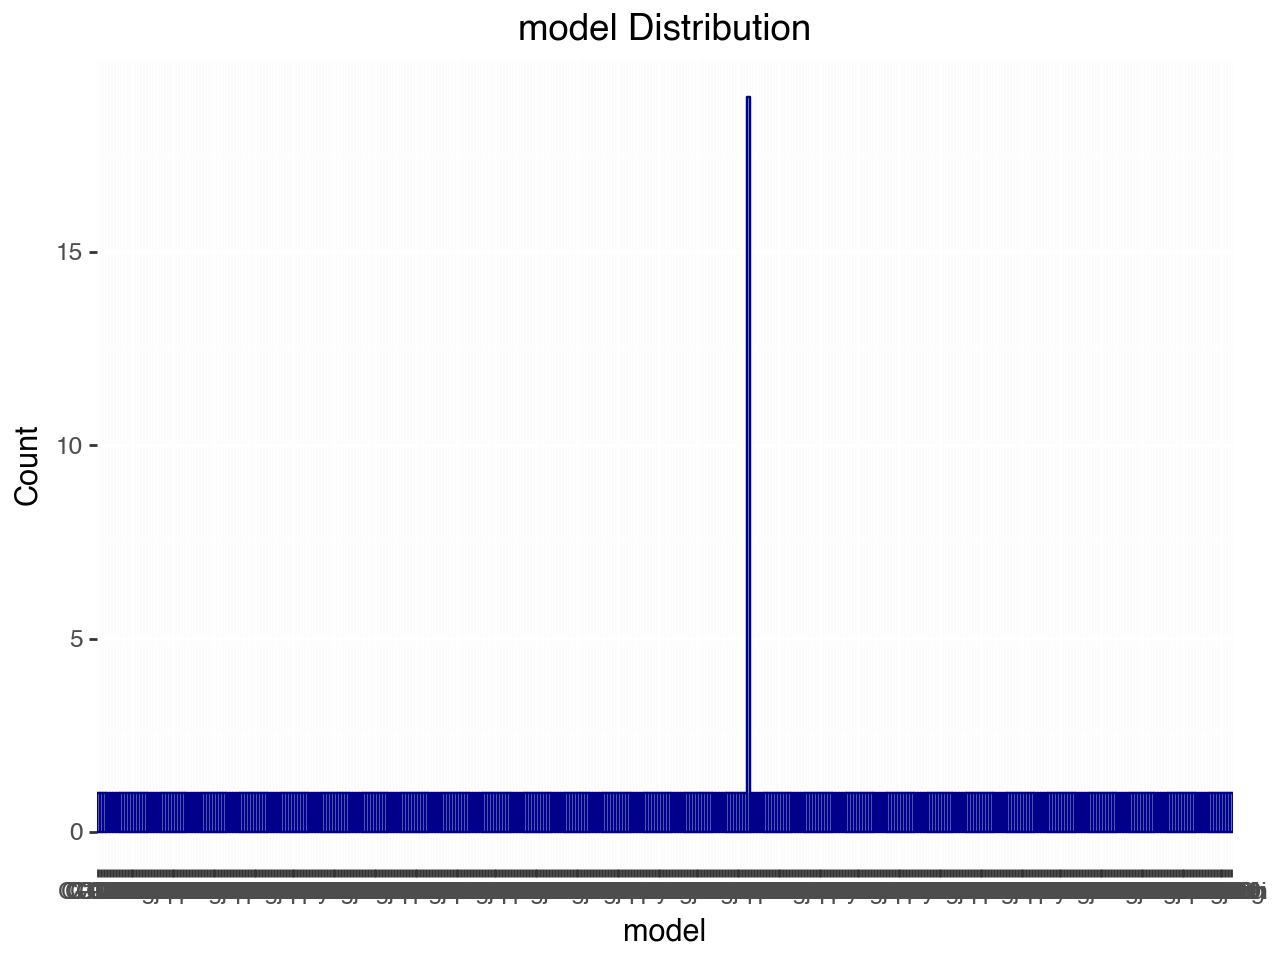

In [119]:
(ggplot(carsopt_clean, aes(x='model'))
 + geom_bar(fill='lightblue', color='darkblue', alpha=0.7)
 + labs(title='model Distribution', x='model', y='Count'))

In [135]:
# let's find that model and see what's up with it
carsopt_clean['model'].value_counts()[carsopt_clean['model'].value_counts() > 1]

model
L-150    19
Name: count, dtype: int64

In [136]:
carsopt_clean[carsopt_clean['model'] == 'L-150']

,model,mpg,cylinders,displacement,horsepower,weight,acceleration,origin,vehicle,prefix
222,L-150,13.0,8,318.0,150,3755,14.0,US,Luxury,L
223,L-150,31.5,4,98.0,68,2045,18.5,Japan,Luxury,L
224,L-150,30.0,4,111.0,80,2155,14.8,US,Luxury,L
225,L-150,21.5,4,79.0,58,1825,18.6,Europe,Luxury,L
226,L-150,25.5,4,122.0,96,2300,15.5,US,Luxury,L
227,L-150,33.5,4,85.0,70,1945,16.8,Japan,Luxury,L
228,L-150,17.5,8,305.0,145,3880,12.5,US,Luxury,L
229,L-150,17.0,8,260.0,110,4060,19.0,US,Luxury,L
230,L-150,15.5,8,318.0,145,4140,13.7,US,Luxury,L
231,L-150,15.0,8,302.0,130,4295,14.9,US,Luxury,L


**Notes** Looks good, just variation

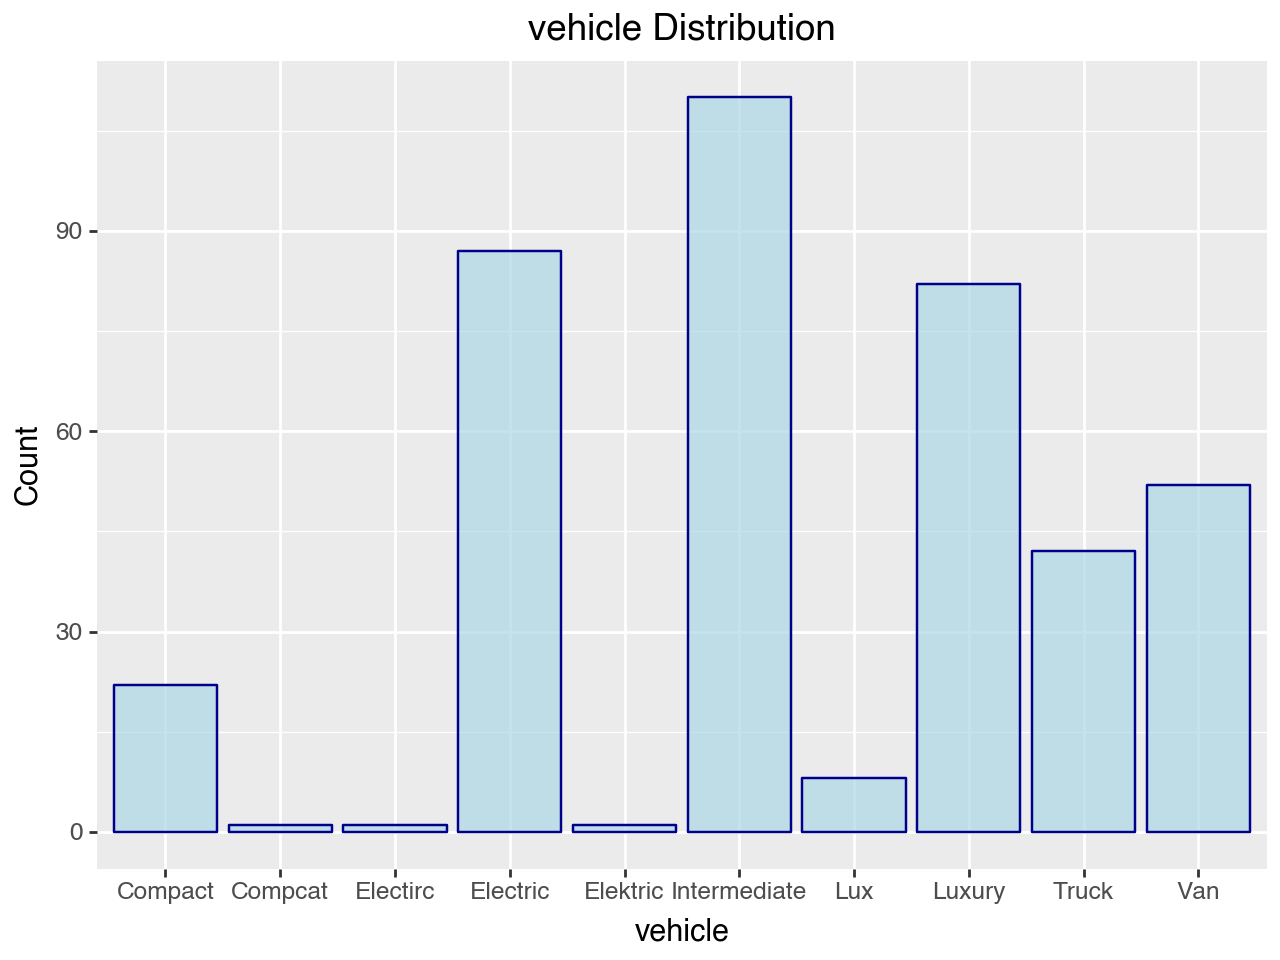

In [120]:
(ggplot(carsopt_clean, aes(x='vehicle'))
 + geom_bar(fill='lightblue', color='darkblue', alpha=0.7)
 + labs(title='vehicle Distribution', x='vehicle', y='Count'))

**Notes:**
The data is cleansed, let's answer some car questions!!!

##### What is the heaviest vehicle?

In [138]:
carsopt_clean.loc[carsopt_clean['weight'].idxmax(), ['model', 'vehicle', 'weight']]

model        E-350a
vehicle    Electric
weight         5140
Name: 51, dtype: object

##### What is the car with the highest fuel efficiency?

In [139]:
carsopt_clean.loc[carsopt_clean['mpg'].idxmax(), ['model', 'vehicle', 'mpg']]

model        E-100g
vehicle    Electric
mpg           130.0
Name: 6, dtype: object

##### Determine the average fuel efficiency of each type of vehicle

/Users/jeffgoseland/miniconda3/lib/python3.12/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 10 rows containing non-finite values.


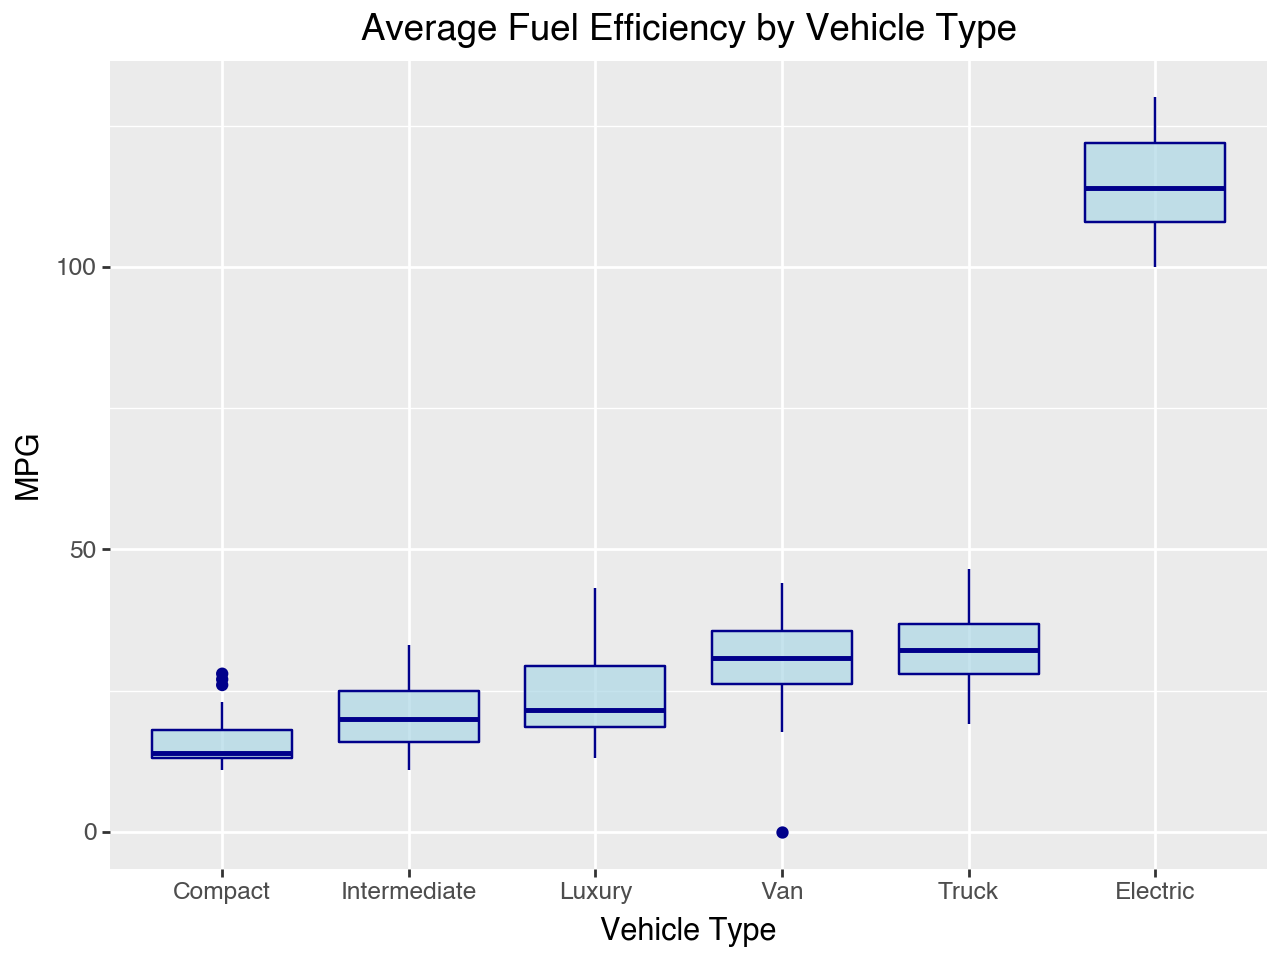

In [141]:

mpg_order = carsopt_clean.groupby('vehicle')['mpg'].mean().sort_values().index.tolist()

(ggplot(carsopt_clean, aes(x='vehicle', y='mpg'))
 + geom_boxplot(fill='lightblue', color='darkblue', alpha=0.7)
 + scale_x_discrete(limits=mpg_order)
 + labs(title='Average Fuel Efficiency by Vehicle Type', x='Vehicle Type', y='MPG'))

In [143]:
print(carsopt_clean.groupby('vehicle')['mpg'].mean().round(2))

vehicle
Compact          16.48
Electric        114.58
Intermediate     21.13
Luxury           23.66
Truck            32.49
Van              29.59
Name: mpg, dtype: float64


#### Test Train Split

#### Modeling

#### Summary / What did we learn

blah